<h1 style="text-align: center;">AAL Sales Analysis Report</h1>


### Import Libraries


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

### Load Data

In [2]:
#Load data
df = pd.read_csv('AusApparalSales4thQrt2020.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
revenue_by_state = (df.groupby('State', as_index = False)['Sales'].sum().sort_values(by = "Sales", ascending=False))
revenue = (df.groupby('Group', as_index = False)['Sales'].sum().sort_values(by = "Sales", ascending = False))
revenue_by_time = (df.groupby('Time', as_index = False)['Sales'].sum().sort_values(by = "Sales", ascending=False))
daily_report = df.resample('D').sum()
weekly_report = df.resample('W').sum()
monthly_report = df.resample('M').sum()
quarterly_report = df.resample('Q').sum()
print("\nShape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 12 rows:\n\n", df.head(12))
print("\nLast 12 rows:\n\n", df.tail(12))
print("\nUnique States:\n", df['State'].unique(), "\n")



Shape: (7560, 5)

Columns: ['Time', 'State', 'Group', 'Unit', 'Sales']

First 12 rows:

                   Time State     Group  Unit  Sales
Date                                               
2020-10-01     Morning    WA      Kids     8  20000
2020-10-01     Morning    WA       Men     8  20000
2020-10-01     Morning    WA     Women     4  10000
2020-10-01     Morning    WA   Seniors    15  37500
2020-10-01   Afternoon    WA      Kids     3   7500
2020-10-01   Afternoon    WA       Men    10  25000
2020-10-01   Afternoon    WA     Women     3   7500
2020-10-01   Afternoon    WA   Seniors    11  27500
2020-10-01     Evening    WA      Kids    15  37500
2020-10-01     Evening    WA       Men    15  37500
2020-10-01     Evening    WA     Women     3   7500
2020-10-01     Evening    WA   Seniors    10  25000

Last 12 rows:

                   Time State     Group  Unit  Sales
Date                                               
2020-12-30     Morning   TAS      Kids    10  25000
2020-12-3

### 1. Data Wrangling

In [3]:
print("\nMissing values:\n\n", df.isna().sum())
print("\nCorrect Entry Data Type: \n\n",df.notna())
print("\n", df.info())


Missing values:

 Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

Correct Entry Data Type: 

             Time  State  Group  Unit  Sales
Date                                       
2020-10-01  True   True   True  True   True
2020-10-01  True   True   True  True   True
2020-10-01  True   True   True  True   True
2020-10-01  True   True   True  True   True
2020-10-01  True   True   True  True   True
...          ...    ...    ...   ...    ...
2020-12-30  True   True   True  True   True
2020-12-30  True   True   True  True   True
2020-12-30  True   True   True  True   True
2020-12-30  True   True   True  True   True
2020-12-30  True   True   True  True   True

[7560 rows x 5 columns]
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7560 entries, 2020-10-01 to 2020-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Time    7560 non-null   object
 1   State   7560 non-null   object
 2   Group   7560 n

#### Recommendations for missing and/or incorrect data values

1. Missing data should be dropped when minimal and random. 
2. They should be filled when essential.
3. Incorrect data should be corrected, standardized, or removed using domain knowledge to preserve data integrity.

#### Data Normalization 

In [4]:
num_cols = ['Unit', 'Sales']
df_normalized = df.copy()

for col in num_cols:
    df_normalized[col] = (
        (df[col] - df[col].min()) /
        (df[col].max() - df[col].min())
    )

df_normalized


,Time,State,Group,Unit,Sales
Date,,,,,
2020-10-01,Morning,WA,Kids,0.095238,0.095238
2020-10-01,Morning,WA,Men,0.095238,0.095238
2020-10-01,Morning,WA,Women,0.031746,0.031746
2020-10-01,Morning,WA,Seniors,0.206349,0.206349
2020-10-01,Afternoon,WA,Kids,0.015873,0.015873
...,...,...,...,...,...
2020-12-30,Afternoon,TAS,Seniors,0.190476,0.190476
2020-12-30,Evening,TAS,Kids,0.206349,0.206349
2020-12-30,Evening,TAS,Men,0.206349,0.206349


- This technique rescales the data to a fixed ranged.
- It ensure no variable dominates due to scale
- It works well with skewed data and does not assume that the data is normally distributed


#### Some insight on the Groupby() function

The GroupBy() function is best fit for merging effects. Given a datasets with data entries that are related by different factors such as state, group, or time, one can use the GroupBy() function to get sample statistics by merging the data values as according to their corresponding common attributes.

### 2. Data Analysis and Visualization

###### Notice: 
1. For descriptive statistics, a box plot was used to visualize the data. This choice of chart enables us to have a deeper glance at the sample data and how the measures of central tendency are distributed around the mean. The box plot shows the minimum and maximum values of the units sold and sales in total, the 25th, 50th and 75th percentile elements.
2. For any other plots the searborn distribution chart (histplot) was used for a clear visual of how the data values are scattered or concentrated across different states, times-of-the-day, groups, days, weeks and months of the quarter.

#### Descriptive Statistics - Sales and Unit: 


               Unit          Sales
count  7560.000000    7560.000000
mean     18.005423   45013.558201
std      12.901403   32253.506944
min       2.000000    5000.000000
25%       8.000000   20000.000000
50%      14.000000   35000.000000
75%      26.000000   65000.000000
max      65.000000  162500.000000


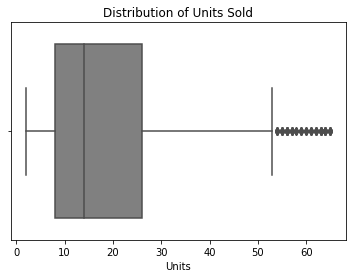

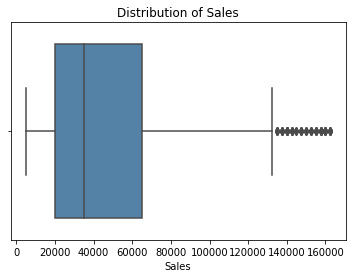

In [5]:
print("\n",df[['Unit', 'Sales']].describe())
sns.boxplot(x=df['Unit'], color = 'grey')
plt.title('Distribution of Units Sold')
plt.xlabel('Units')
plt.show()

sns.boxplot(x=df['Sales'], color = 'steelblue')
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.show()



##### Inferential Findings

1. The box diagram of the units and sales values correspond in relation to measures of central tendency's positions.
2. Both diagrams are skewed to the right i.e they are positively skewed.
3. There is visible evidence of outliers in the dataset.
4. The outliers could be business driven and be a result of promotions that might has been ran during the festive season holidays.
5. The mean is greater than the median.
6. The dataset is not symmetrically distributed.
7. There is a greater variation.

#### State-wise Sales Analysis


Highest: 
 State      Sales
  VIC  105565000
  NSW   74970000
   SA   58857500 

Lowest: 
 State     Sales
  TAS  22760000
   NT  22580000
   WA  22152500


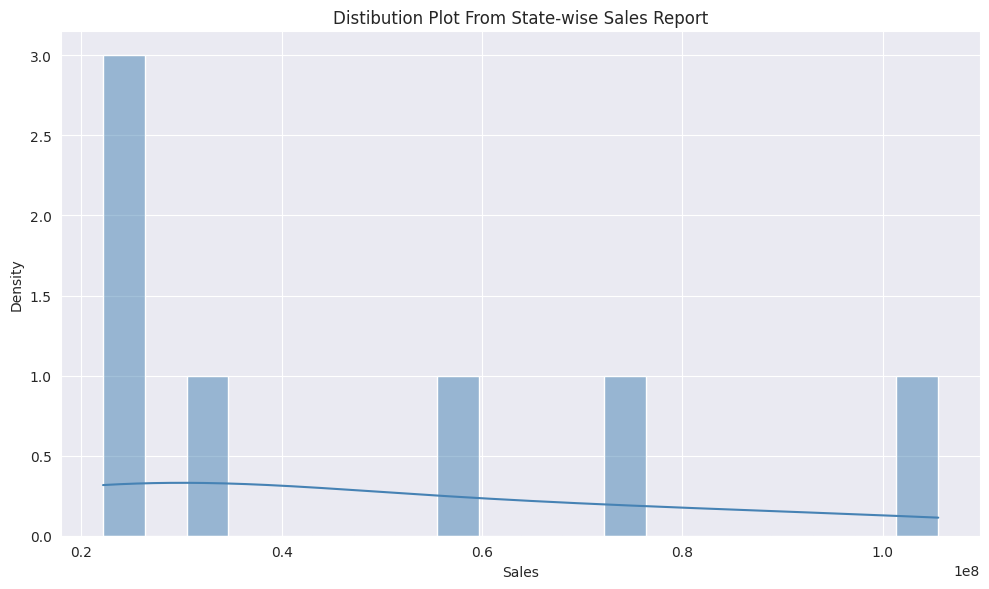

In [6]:
#print(revenue_by_state)
print("\nHighest: \n",revenue_by_state.head(3).to_string(index=False),"\n") 
print("Lowest: \n",revenue_by_state.tail(3).to_string(index=False))

sns.set_style('darkgrid')
plt.figure(figsize = (10,6), dpi = 100)

plt.title("Distribution Plot From State-wise Sales Report")

sns.histplot(
    data = revenue_by_state,
    x = "Sales",
    kde = True,
    bins = 20,
    color = "steelblue"
)

plt.title("Distibution Plot From State-wise Sales Report")
plt.xlabel("Sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

##### Inferential Findings

1. The VIS, NSW and SA are the three states that have generated the highest sales revenue in total for the 4th quarter of 2020.
2. The TAS, NT and WA states are the states that have generated the lowest sales revenue in total for the 4th quarter of 2020.
3. The chart visualizations indicates a unimodal distribution.

#### Group-wise Sales Analysis


Highest Sales: 
 Group     Sales
  Men  85750000 

Lowest Sales: 
     Group     Sales
  Seniors  84037500


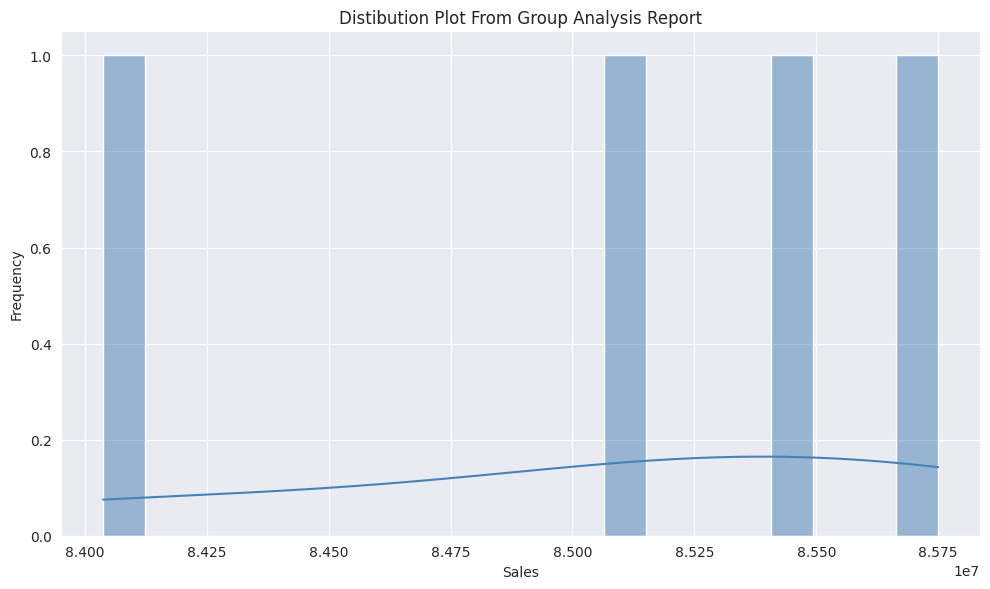

In [7]:
#print("\n",revenue)
print("\nHighest Sales: \n",revenue.head(1).to_string(index=False),"\n") 
print("Lowest Sales: \n",revenue.tail(1).to_string(index=False))

#Groupwise Sales Visualization
sns.set_style('darkgrid')
plt.figure(figsize = (10,6), dpi = 100)

plt.title("Distribution Plot From Group Analysis Report")

sns.histplot(
    data = revenue,
    x = "Sales",
    kde = True,
    bins = 20,
    color = "steelblue"
)

plt.title("Distibution Plot From Group Analysis Report")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

##### Inferential Findings

1. The distribution is relatively flat, indicating no strong skewness.
2. The sales data pertaining groups is not continuous but rather consist of discrete values.
3. It has multiple peaks hence it is multimodal.
4. The group with the highest sales is that of men.
5. The group with the lowest sales is that of seniors.

#### Time-of-the-day Sales Analysis

       Time      Sales
    Morning  114207500
  Afternoon  114007500
    Evening  112087500


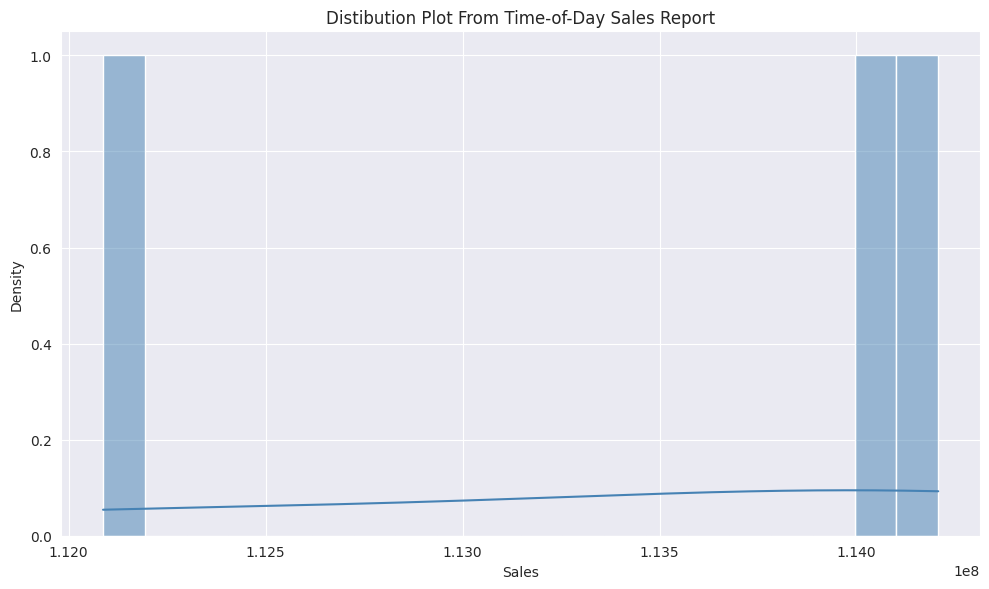

In [8]:
#Time-of-the-day Sales Visualization
print(revenue_by_time.to_string(index=False))
sns.set_style('darkgrid')
plt.figure(figsize = (10,6), dpi = 100)

plt.title("Distribution Plot From Time-of-Day Sales Report")

sns.histplot(
    data = revenue_by_time,
    x = "Sales",
    kde = True,
    bins = 20,
    color = "steelblue"
)

plt.title("Distibution Plot From Time-of-Day Sales Report")
plt.xlabel("Sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

##### Inferential Findings

1. Almost the same perfomance in relation to the time of the day is obtained across all times (morning, afternoon and evening).
2. There is an uneven distribution of sales across all time of all the days in the quarter.
3. The time of the day with the insignificantly highest number of sales is during the morning and the time of day with the insignificantly lowest number of sales is during the evening.


#### Daily Sales Analysis

            Unit    Sales
Date                     
2020-10-01  1488  3720000
2020-10-02  1486  3715000
2020-10-03  1556  3890000
2020-10-04  1488  3720000
2020-10-05  1545  3862500 



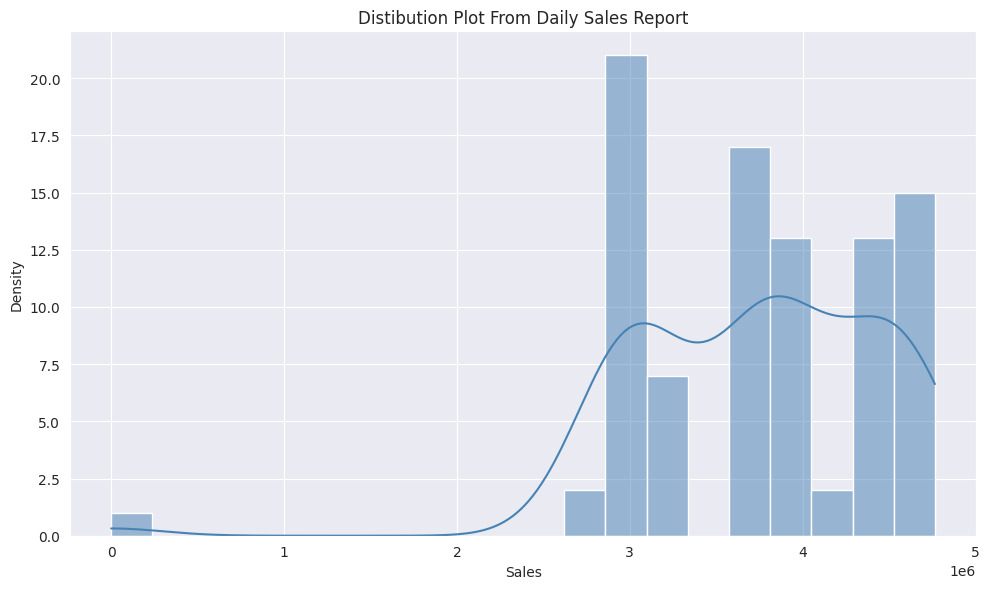

In [9]:
print(daily_report.head(), "\n")
#Daily Report Visualization
sns.set_style('darkgrid')
plt.figure(figsize = (10,6), dpi = 100)

plt.title("Distribution Plot From Daily Sales Report")

sns.histplot(
    data = daily_report,
    x = "Sales",
    kde = True,
    bins = 20,
    color = "steelblue"
)

plt.title("Distibution Plot From Daily Sales Report")
plt.xlabel("Sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


##### Inferential Findings

1. Most sales are concentrated between 3 million and 5 million.
2. There are few sales below 2 million.
3. There are two main peaks, around 3 million and 4 million sales and this suggests bimodal distribution.
4. The sales are not evenly distributed, the cluster around specific values.
5. Very low sales are rare across all the days of the quarter.

#### Weekly Report

             Unit     Sales
Date                       
2020-10-04   6018  15045000
2020-10-11  10801  27002500
2020-10-18  10656  26640000
2020-10-25  10726  26815000
2020-11-01   8723  21807500 



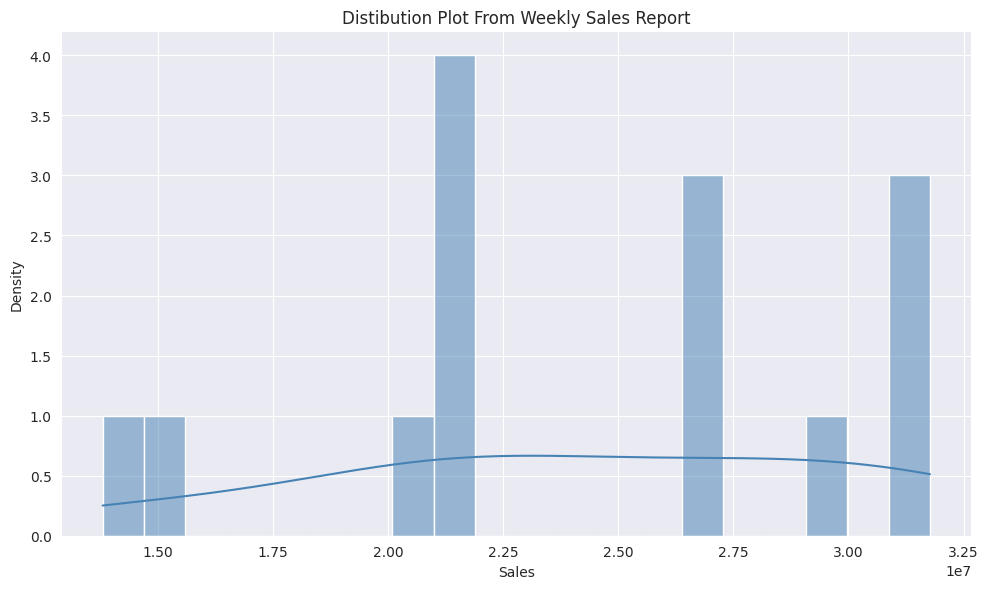

In [10]:
print(weekly_report.head(), "\n")

# Weekly Report Visualization
sns.set_style('darkgrid')
plt.figure(figsize = (10,6), dpi = 100)

plt.title("Distribution Plot From Weekly Sales Report")

sns.histplot(
    data = weekly_report,
    x = "Sales",
    kde = True,
    bins = 20,
    color = "steelblue"
)

plt.title("Distibution Plot From Weekly Sales Report")
plt.xlabel("Sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

##### Inferential Findings

1. The sales data does not follow a perfect normal distribution, instead it shows multiple peaks.
2. Multimodal distribution can be observed from the chart.
3. Sales are clustered around certain values and one possible reason for this could be seasonal effects, promotions or market cycles.

#### Monthly Report

             Unit      Sales
Date                        
2020-10-31  45716  114290000
2020-11-30  36273   90682500
2020-12-31  54132  135330000


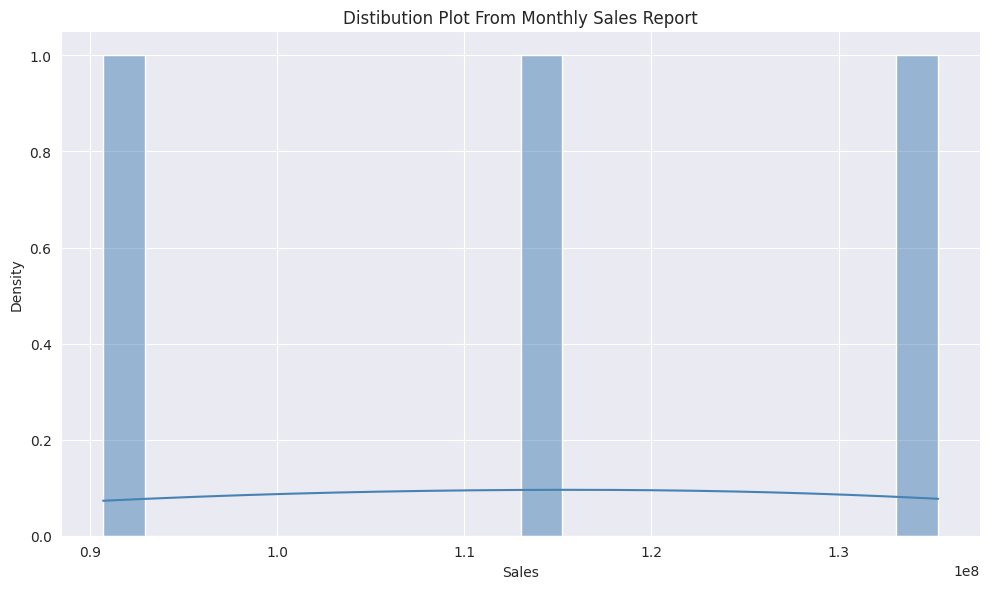

In [11]:
print(monthly_report.head())

# Monthly Report Visualization
sns.set_style('darkgrid')
plt.figure(figsize = (10,6), dpi = 100)

plt.title("Distribution Plot From Monthly Sales Report")

sns.histplot(
    data = monthly_report,
    x = "Sales",
    kde = True,
    bins = 20,
    color = "steelblue"
)

plt.title("Distibution Plot From Monthly Sales Report")
plt.xlabel("Sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()


##### Inferential Findings

1. The distribution is multimodal as it has multiple peaks.
2. The sales are clustered around specific values and this could be because  different states, groups, times of the day with distinct sales levels.
3. The month with the highest number of sales is December, and the month with the lowest number of sales is November.

#### Quarterly Report

              Unit      Sales
Date                         
2020-12-31  136121  340302500


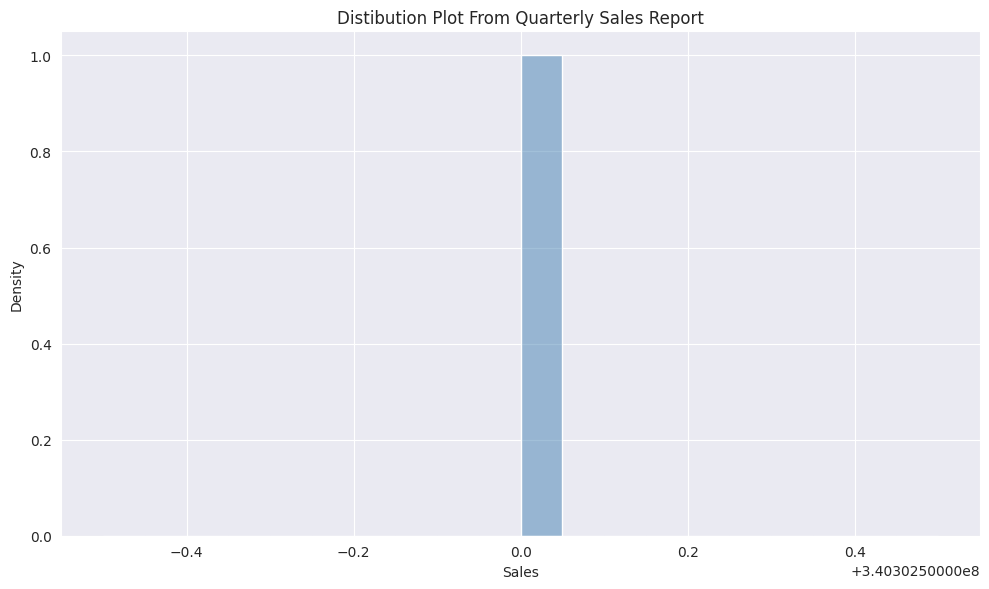

In [12]:
print(quarterly_report.head())

# Quarterly Report Visualization
sns.set_style('darkgrid')
plt.figure(figsize = (10,6), dpi = 100)

plt.title("Distribution Plot From Quarterly Sales Report")

sns.histplot(
    data = quarterly_report,
    x = "Sales",
    kde = True,
    bins = 20,
    color = "steelblue"
)

plt.title("Distibution Plot From Quarterly Sales Report")
plt.xlabel("Sales")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

### Conclusion

The 4th quarter of the year 2020 performed significantly well in terms of sales revenue considering all the states, groups and times of the days. Nevertheless, some states performed significantly well compared to other states.

### Sales Program for Low Sales-Revenue Performing States 

- Initiate targeted sales programs by state type.
- Run time-bound discounts such as payday promos or month-end deals.
- Offer bulk-purchase incentives.
- Improve market awareness in those states.
- Invest in advertizing market.
- Run instore activations and demos.
- Ensure there are not any limitations to the distribution of units in those states.
- Prioritize products that are best-selling in those states.